## Introduction

Name  : Stefano Veronigo Wijaya

##

## Problem Statement and Dataset Description

Problem Statement: To identify whether review length and community voting data are associated with user recommendation outcomes (recommended vs not recommended) in Steam game reviews.

- Specific: Check for correlations between review length and community voting patterns with user recommendation  
- Measurable: Uses the length of the review and community vote from recommended and not recommended reviews  
- Achievable: Use the available dataset and using inferentials  
- Relevant: Can be useful for gamedevs to check for serious reviews that might be game-changing for them  
- Time-bound: identify based on the available time period

5W+1H

- What: What is the average review length between positive and negative reviews?
- Who: Who are more likely to give opinions in reviews?
- Why: Why might certain reviews receive more positive community votes?
- When: When can there be an imbalance between positive and negative reviews?
- Where: Where does positive or negative reviews appear often?
- How: How strong are review datas related to each other?

##

## Data Loading

In [1]:
import pandas as pd
from scipy import stats
import numpy as np

 Link dataset: (https://www.kaggle.com/datasets/andrewmvd/steam-reviews/data)

In [ ]:
df = pd.read_csv("steam-reviews.csv")

In [7]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6417106 entries, 0 to 6417105
Data columns (total 5 columns):
 #   Column        Non-Null Count    Dtype 
---  ------        --------------    ----- 
 0   app_id        6417106 non-null  int64 
 1   app_name      6233872 non-null  object
 2   review_text   6409801 non-null  object
 3   review_score  6417106 non-null  int64 
 4   review_votes  6417106 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 244.8+ MB


With the code above, we can insinuate that there are some empty data within the app_name column and review_text column.

In [8]:
df.isnull().sum()

app_id               0
app_name        183234
review_text       7305
review_score         0
review_votes         0
dtype: int64

We can see that there are 183234 missing data in the app_name column and 7305 missing data in review_text.

##

## Data Cleaning

Remove missing datas using df.dropna()

In [45]:
df1 = df.copy() #make a copy of the dataframe just in case

df1 = df1.dropna()

df1

,app_id,app_name,review_text,review_score,review_votes
0,10,Counter-Strike,Ruined my life.,1,0
1,10,Counter-Strike,This will be more of a ''my experience with th...,1,1
2,10,Counter-Strike,This game saved my virginity.,1,0
3,10,Counter-Strike,• Do you like original games? • Do you like ga...,1,0
4,10,Counter-Strike,"Easy to learn, hard to master.",1,1
...,...,...,...,...,...
6417101,99910,Puzzle Pirates,I really ove this game but it needs somethings...,-1,0
6417102,99910,Puzzle Pirates,"Used to play Puzzel Pirates 'way back when', b...",-1,0
6417103,99910,Puzzle Pirates,"This game was aright, though a bit annoying. W...",-1,0
6417104,99910,Puzzle Pirates,"I had a nice review to recommend this game, bu...",-1,0


Data frame has been trimmed down with the removal of the missing datas in app_name and review_text column.

In [46]:
df1.isnull().sum()

app_id          0
app_name        0
review_text     0
review_score    0
review_votes    0
dtype: int64

With this, we can confirm that there are no more missing datas

##

Renaming columns to look more presentable.

In [47]:
df1.rename(columns={
    "app_id" : "App ID",
    "app_name" : "App Name",      
    "review_text" : "Review Text",
    "review_score" : "Review Score",
    "review_votes" : "Review Votes",
}, inplace = True)

Make the Review columns show Recommended and Not Recommended instead of numbers.

In [48]:
df1["Review Score"] = df1["Review Score"].map({
    1: "Recommended",
    -1: "Not Recommended"
})

df1["Review Votes"] = df1["Review Votes"].map({
    1: "Helpful",
    0: "Not Helpful"
})

In [49]:
df1

,App ID,App Name,Review Text,Review Score,Review Votes
0,10,Counter-Strike,Ruined my life.,Recommended,Not Helpful
1,10,Counter-Strike,This will be more of a ''my experience with th...,Recommended,Helpful
2,10,Counter-Strike,This game saved my virginity.,Recommended,Not Helpful
3,10,Counter-Strike,• Do you like original games? • Do you like ga...,Recommended,Not Helpful
4,10,Counter-Strike,"Easy to learn, hard to master.",Recommended,Helpful
...,...,...,...,...,...
6417101,99910,Puzzle Pirates,I really ove this game but it needs somethings...,Not Recommended,Not Helpful
6417102,99910,Puzzle Pirates,"Used to play Puzzel Pirates 'way back when', b...",Not Recommended,Not Helpful
6417103,99910,Puzzle Pirates,"This game was aright, though a bit annoying. W...",Not Recommended,Not Helpful
6417104,99910,Puzzle Pirates,"I had a nice review to recommend this game, bu...",Not Recommended,Not Helpful


The dataframe now looks easier to look at and comprehend compared to before.

In [50]:
df2 = df1.copy()

df2

,App ID,App Name,Review Text,Review Score,Review Votes
0,10,Counter-Strike,Ruined my life.,Recommended,Not Helpful
1,10,Counter-Strike,This will be more of a ''my experience with th...,Recommended,Helpful
2,10,Counter-Strike,This game saved my virginity.,Recommended,Not Helpful
3,10,Counter-Strike,• Do you like original games? • Do you like ga...,Recommended,Not Helpful
4,10,Counter-Strike,"Easy to learn, hard to master.",Recommended,Helpful
...,...,...,...,...,...
6417101,99910,Puzzle Pirates,I really ove this game but it needs somethings...,Not Recommended,Not Helpful
6417102,99910,Puzzle Pirates,"Used to play Puzzel Pirates 'way back when', b...",Not Recommended,Not Helpful
6417103,99910,Puzzle Pirates,"This game was aright, though a bit annoying. W...",Not Recommended,Not Helpful
6417104,99910,Puzzle Pirates,"I had a nice review to recommend this game, bu...",Not Recommended,Not Helpful


Add a Column with the name of Review Length which is how long each review in Review Text is.

In [51]:
df2["Review Length"] = df2["Review Text"].astype(str).str.len()

In [52]:
df2.dtypes

App ID            int64
App Name         object
Review Text      object
Review Score     object
Review Votes     object
Review Length     int64
dtype: object

In [53]:
df2

,App ID,App Name,Review Text,Review Score,Review Votes,Review Length
0,10,Counter-Strike,Ruined my life.,Recommended,Not Helpful,15
1,10,Counter-Strike,This will be more of a ''my experience with th...,Recommended,Helpful,2357
2,10,Counter-Strike,This game saved my virginity.,Recommended,Not Helpful,29
3,10,Counter-Strike,• Do you like original games? • Do you like ga...,Recommended,Not Helpful,220
4,10,Counter-Strike,"Easy to learn, hard to master.",Recommended,Helpful,48
...,...,...,...,...,...,...
6417101,99910,Puzzle Pirates,I really ove this game but it needs somethings...,Not Recommended,Not Helpful,537
6417102,99910,Puzzle Pirates,"Used to play Puzzel Pirates 'way back when', b...",Not Recommended,Not Helpful,543
6417103,99910,Puzzle Pirates,"This game was aright, though a bit annoying. W...",Not Recommended,Not Helpful,281
6417104,99910,Puzzle Pirates,"I had a nice review to recommend this game, bu...",Not Recommended,Not Helpful,379


Due to the fact that we are trying to find the correlation between User Recommendation, Review Length, and Review Votes, we can safely take a smaller sample of 500k data with a 50/50 split of it being Recommended and Not Recommended.

In [54]:
df3 = df2.copy()

recommended = df3[df3["Review Score"] == "Recommended"].sample(250000, random_state=50)
not_recommended = df3[df3["Review Score"] == "Not Recommended"].sample(250000, random_state=50)

df3 = pd.concat([recommended, not_recommended])

We can also remove the Review Text and App ID column because it would not be needed for data analysis since we now have Review Length

In [55]:
df3 = df3.drop(columns=["Review Text", "App ID"])

To make data analysis easier, and also make it faster to load, changing the data type of Review Score, Review Votes, and App Name into category can help by saving memory usage.

In [56]:
df3["App Name"] = df3["App Name"].astype("category")
df3["Review Score"] = df3["Review Score"].astype("category")
df3["Review Votes"] = df3["Review Votes"].astype("category")

In [57]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500000 entries, 1427298 to 430195
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   App Name       500000 non-null  category
 1   Review Score   500000 non-null  category
 2   Review Votes   500000 non-null  category
 3   Review Length  500000 non-null  int64   
dtypes: category(3), int64(1)
memory usage: 9.9 MB


##

## Exploration and Analysis

Import libraries necessary for data visualisation later

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df3.head()

,App Name,Review Score,Review Votes,Review Length
1427298,DayZ,Recommended,Not Helpful,20
5145320,Undertale,Recommended,Not Helpful,150
6268294,BioShock,Recommended,Not Helpful,441
4737469,Clicker Heroes,Recommended,Not Helpful,212
2486843,SNOW,Recommended,Not Helpful,20


## Descriptive

Central Tendency

In [60]:
mean = df3["Review Length"].mean()  #Calculate average
median = df3["Review Length"].median()  #Middle value
mode = df3["Review Length"].mode()  #Which data appears most?

print(f"Mean: {mean},\nMedian:  {median},\nMode:  {mode}")

Mean: 336.811956,
Median:  116.0,
Mode:  0    20
Name: Review Length, dtype: int64


The average length of the reviews are 336 letters (and spaces) with the median being 116 and the length that appears the most are shared between 0 and 20.

##

Outlier Analysis

We will be using Tukey's Rule to see the percentage of outliers

In [61]:
q1 = df3["Review Length"].quantile(0.25)
q3 = df3["Review Length"].quantile(0.75)
iqr = q3-q1

up_bound = q3 + 1.5*iqr
low_bound = q1 - 1.5*iqr

print(f'Upper Boundary: {up_bound:.2f}' )
print(f'Lower Boundary: {low_bound:.2f}')

Upper Boundary: 837.50
Lower Boundary: -454.50


In [62]:
outlier = df3["Review Length"][(df3["Review Length"]<low_bound) | (df3["Review Length"]>up_bound)]
no_outlier = df3["Review Length"][(df3["Review Length"]>=low_bound) & (df3["Review Length"]<=up_bound)]

print(f'Percentage of outliers: {len(outlier)*100/len(df3["Review Length"]):.2f}%')

Percentage of outliers: 10.19%


There are around 10% of outliers in the current dataframe, and almost certainly Positive Skewed (due to the mean being higher than both median and mode).

##

Removal of Extreme Outliers

In [63]:
df4 = df3.copy()

df4 = df4[
    (df4["Review Length"] >= low_bound) &
    (df4["Review Length"] <= up_bound)]

df4

,App Name,Review Score,Review Votes,Review Length
1427298,DayZ,Recommended,Not Helpful,20
5145320,Undertale,Recommended,Not Helpful,150
6268294,BioShock,Recommended,Not Helpful,441
4737469,Clicker Heroes,Recommended,Not Helpful,212
2486843,SNOW,Recommended,Not Helpful,20
...,...,...,...,...
951557,FTL: Faster Than Light,Not Recommended,Not Helpful,135
5747692,The Sims(TM) 3,Not Recommended,Not Helpful,112
2810134,Rust,Not Recommended,Not Helpful,20
2769337,Rust,Not Recommended,Not Helpful,20


Confirm removal of Extreme Outliers

In [64]:
outlier = df4["Review Length"][(df4["Review Length"]<low_bound) | (df4["Review Length"]>up_bound)]
no_outlier = df4["Review Length"][(df4["Review Length"]>=low_bound) & (df4["Review Length"]<=up_bound)]

print(f'Percentage of outliers: {len(outlier)*100/len(df4["Review Length"]):.2f}%')

Percentage of outliers: 0.00%


After making sure that there are no more outliers, we are left with 449k rows which means around 50k data has more than 837 letters in the review which were extreme outliers and would be safer and more accurate if we remove them.

Central Tendency after Outlier Removal

In [65]:
mean = df4["Review Length"].mean()  #Calculate average
median = df4["Review Length"].median()  #Middle value
mode = df4["Review Length"].mode()  #Which data appears most?

print(f"Mean: {mean},\nMedian:  {median},\nMode:  {mode}")

Mean: 172.67712404328142,
Median:  92.0,
Mode:  0    20
Name: Review Length, dtype: int64


The average length of the reviews after outlier removal are 172 letters (and spaces) with the median being 92 and the length that appears the most are sstill shared between 0 and 20. This concludes that the outlier quite heavily impacts the Central Tendency.

##

## Inferential

Confidence Interval

Confidence Interval between the mean review length of both recommended and not recommended Review Scores

In [30]:
rec = df4[df4["Review Score"] == "Recommended"]["Review Length"]
not_rec = df4[df4["Review Score"] == "Not Recommended"]["Review Length"]    #Separate for comparison 

lenrec = len(rec)
lennrec = len(not_rec)  #Calculate sample sizes

mean1 = rec.mean()
mean2 = not_rec.mean()  #Calculate means

std1 = rec.std()
std2 = not_rec.std()    #Calculate standard deviations

se_diff = np.sqrt((std1**2 / lenrec) + (std2**2 / lennrec)) #Calculate standard error of the difference between the two

mean_diff = mean1 - mean2   #Calculate mean difference

low, up = stats.norm.interval(
    0.95,   # Calculate 95% confidence interval for mean difference
    loc=mean_diff,       
    scale=se_diff        
)

# Display results
print("Mean Difference:", mean_diff)
print("Lower Limit:", low)
print("Upper Limit:", up)

Mean Difference: -27.05245317055099
Lower Limit: -28.177306261578707
Upper Limit: -25.927600079523273


Since the results are in the negatives, we know that Recommended Reviews has 27 words **less** than those of Not Recommended Reviews. This is to be expected because logically, people would type out their complaints about the game and usually tell (usually in detail) how the developers can improve their game although some positive reviews do tell the readers about how good a game is (in detail) which is why the difference is not THAT great.

##

Hypothesis Test

Even if we have proven using the Confidence Interval method, we can also use the Hypothesis Test to make the statement more concrete.

H0 = No significant difference in the mean of the Review Length between the two groups  
H1 = There is a significant difference in the mean of the Review Length  

Two-Sample Independent Test

In [31]:
t_stat, p_value = stats.ttest_ind(rec, not_rec, alternative="two-sided") #We can reuse the variables from the cells above

print(f"T-Statistic: {t_stat}")
print(f"P-Value: {p_value}")

T-Statistic: -47.254558881809665
P-Value: 0.0


We can **reject** H0 and confirm that **There is** a difference in the mean of the Review Length between the two groups (Recommended and Not Recommended)

##

Data Visualisation

Bar Plot

<function matplotlib.pyplot.show(close=None, block=None)>

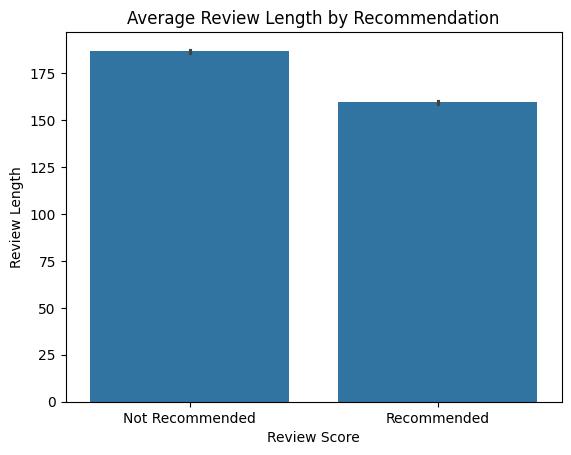

In [67]:
sns.barplot(data = df4,         #Where the data is taken
            x = "Review Score", #X Axis
            y = "Review Length" #Y Axis
            )

plt.title("Average Review Length by Recommendation")
plt.show

Average Review Length of Not Recommended is slightly higher than that of the Recommended reviews by looking at the current bar plot although not by much.

Box Plot

<function matplotlib.pyplot.show(close=None, block=None)>

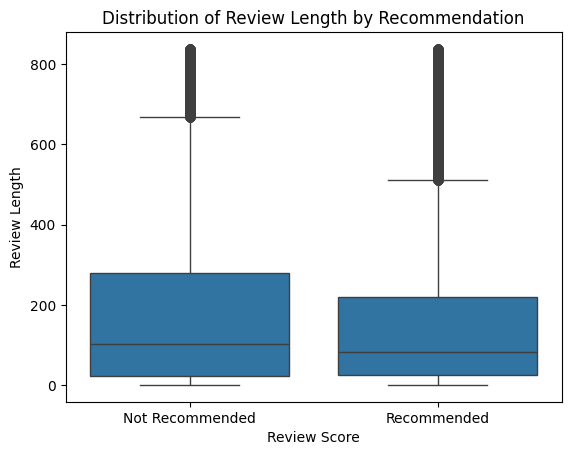

In [68]:
sns.boxplot(
    x = "Review Score",
    y = "Review Length",
    data = df4
    )

plt.title ("Distribution of Review Length by Recommendation")
plt.show

Not Recommended reviews shows a higher median Review Length compared to Recommended ones. It also appears slightly more spread out which suggests that negative reviews tend to be longer.

Heatmap

Since our data is categorical, we need to do create a frequency table that shows the relationship between Review Scores and Review Votes.

In [69]:
pd.crosstab(df4["Review Score"],df4["Review Votes"], normalize = "index")

Review Votes,Helpful,Not Helpful
Review Score,,
Not Recommended,0.234283,0.765717
Recommended,0.122632,0.877368


Text(0.5, 1.0, 'Agreement Between Reviewer and Community')

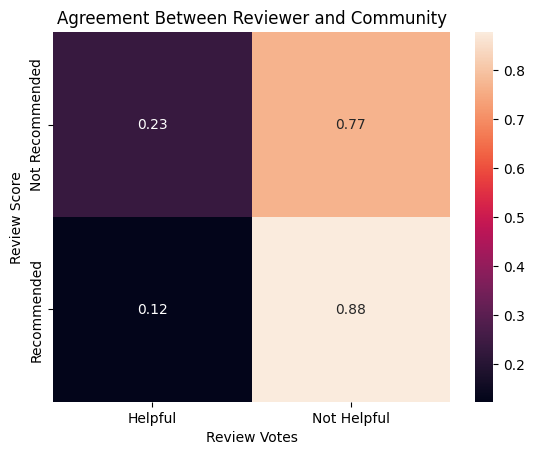

In [70]:
sns.heatmap(pd.crosstab(df4["Review Score"],df4["Review Votes"], normalize = "index"),
            annot= True,
            )

plt.title("Agreement Between Reviewer and Community")

The community tend to favor negative reviews more than they do positive. This can possibly be due to the fact that some people prefer to have someone else point out what they think about the game rather than making their own statement, whereas people might have a different perspective with what they find positive. Hence the difference in Review Votes towards positive and negative reviews.

Violin Plot

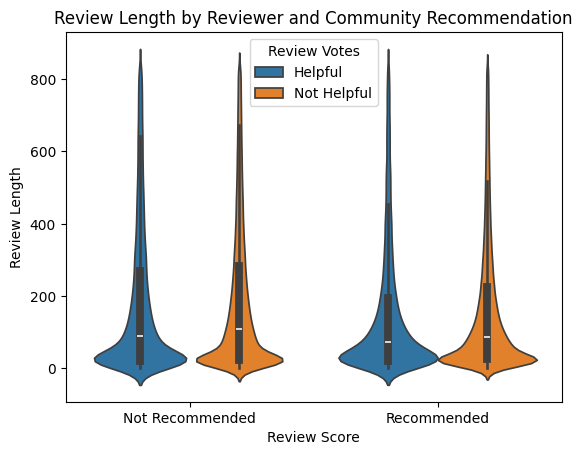

In [71]:
sns.violinplot(x = "Review Score",
            y = "Review Length",
            hue = "Review Votes",   #Color difference between that data
            data = df4)

plt.title("Review Length by Reviewer and Community Recommendation")
plt.show()

Just like in the visualisations before, it is still consistent that Not Recommended reviews are longer than Recommended ones. Relationship between Review Score and Review Votes according to the graph is quite weak because they almost seem similar in both sides. 

##

Export to .csv for further visualisation in Tableau Public

In [72]:
df4.to_csv("dataset_clean.csv")

##

## Conclusion

The Two-Sample Independent T-Test shows that there is a significant difference between the length of positive and negative reviews. However when comparing Community Votes (Review Votes) towards Review Score, it seems that the community votes are not primarily based on Review Length or Review Score since more often than not, they choose Not Helpful rather than Helpful which means they mostly would not recommend said review. Hence, the relationship between Review Votes towards Review Score is quite weak, but the correlation between Review Score and Review Length is pretty strong. We can also take the conclusion that most of the long reviews that are agreed upon by both the community and the reviewer can be taken seriously in order to improve the product.